<a href="https://colab.research.google.com/github/jiyak2804/Self-pruning-neural-network/blob/main/self_pruning_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import torch
import torchvision
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [14]:
transform=torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_set=torchvision.datasets.CIFAR10(root='/data',train=True,download=True,transform=transform)
test_set=torchvision.datasets.CIFAR10(root='/data',train=False,download=True,transform=transform)


In [15]:
train_loader=torch.utils.data.DataLoader(train_set,batch_size=128,num_workers=2,shuffle=True)
test_loader=torch.utils.data.DataLoader(test_set,batch_size=128,num_workers=2,shuffle=False)


In [16]:
class PrunableLinear(nn.Module):
    def __init__(self,in_features,out_features):
      super(PrunableLinear,self).__init__()
      self.in_features=in_features
      self.out_features=out_features
      # CURRENT — causes gradient explosion

      self.weights = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
      self.bias=nn.Parameter(torch.zeros(out_features))
      self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(25 * self.gate_scores)

        if self.training:
            pruned_weights = self.weights * gates
        else:
            hard_gates     = (gates > 0.1).float()
            pruned_weights = self.weights * hard_gates

        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
      return torch.sigmoid(25*self.gate_scores).detach()

In [17]:
class CNNBlock(nn.Module):
  def __init__(self):
    super(CNNBlock, self).__init__()
    self.fc1=PrunableLinear(3072,1024)
    self.bn1=nn.BatchNorm1d(1024)
    self.fc2=PrunableLinear(1024,512)
    self.bn2=nn.BatchNorm1d(512)
    self.fc3=PrunableLinear(512,256)
    self.bn3=nn.BatchNorm1d(256)
    self.fc4=PrunableLinear(256,10)

  def forward(self,x):
    x=x.view(x.size(0),-1)
    x=F.relu(self.bn1(self.fc1(x)))
    x=F.relu(self.bn2(self.fc2(x)))
    x=F.relu(self.bn3(self.fc3(x)))
    x=self.fc4(x)
    return x

  def prunable_layers(self):
    for module in self.modules():
      if isinstance(module,PrunableLinear):
        yield module

##total prunable weights

net=CNNBlock()
total_prunable_weights=sum(m.weights.numel() for m in net.prunable_layers())
print(f'Total prunable weights:{total_prunable_weights:}')

Total prunable weights:3803648


In [18]:
def sparsity_loss(model):
    total_sum   = 0.0
    total_gates = 0
    for layer in model.prunable_layers():
        total_sum   += torch.abs(layer.gate_scores).pow(1.5).sum()  # raw scores, not sigmoid
        total_gates += layer.gate_scores.numel()
    return total_sum / total_gates   # normalized: always in (0, 1)

def total_loss(logits,labels,model,lam):
  ce=F.cross_entropy(logits,labels)
  sp=sparsity_loss(model)
  return ce+lam*sp,ce.item(),sp.item()



In [19]:
def compute_sparsity(model, threshold=0.1):
    """
    Percentage of weights whose gate value is below threshold.
    threshold=0.1 means gates < 0.1 are considered pruned.
    """
    pruned = 0
    total  = 0
    for layer in model.prunable_layers():
        gates   = layer.get_gates()
        pruned += (gates < threshold).sum().item()
        total  += gates.numel()
    return 100.0 * pruned / total


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds   = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return 100.0 * correct / total


def train_model(lam, epochs=20, lr=1e-3):
    print(f'\n  Training with \u03bb = {lam}')
    model = CNNBlock().to(device)

    # ── Collect gate and weight parameters separately ───────────────────
    gate_params   = [l.gate_scores for l in model.prunable_layers()]
    #weight_params = [l.weights     for l in model.prunable_layers()]
    gate_ids      = {id(p) for p in gate_params}
    other_params  = [p for p in model.parameters() if id(p) not in gate_ids]

    # ── Two separate optimizers ──────────────────────────────────────────
    # Weight optimizer: trained on CE loss (classification)
    #w_optimizer = optim.Adam(weight_params + other_params, lr=lr, weight_decay=1e-4)

    # Gate optimizer: trained on SPARSITY loss ONLY (high lr so gates move fast)
   # g_optimizer = optim.Adam(gate_params, lr=0.1, weight_decay=0.0)
    optimizer = optim.Adam([
        {'params': other_params, 'lr': lr,    'weight_decay': 1e-4},
        {'params': gate_params,  'lr': 5e-3,  'weight_decay': 0.0},  # gates: higher LR, no decay
    ])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    history = {'ce': [], 'sp': [], 'sparsity_pct': [], 'test_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_ce, epoch_sp = 0.0, 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # ── Step 1: Update weights using CE loss ─────────────────────
            logits = model(images)
            ce     = F.cross_entropy(logits, labels)

            if epoch<3:
              loss=ce
              sp=torch.tensor(0.0)
            else:
              sp=sparsity_loss(model)
              loss=ce+lam*sp


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_ce += ce.item()
            epoch_sp += sp.item()

        scheduler.step()

        sp_pct   = compute_sparsity(model)
        test_acc = evaluate(model, test_loader)

        history['ce'].append(epoch_ce / len(train_loader))
        history['sp'].append(epoch_sp / len(train_loader))
        history['sparsity_pct'].append(sp_pct)
        history['test_acc'].append(test_acc)

        print(f'Epoch {epoch:2d}/{epochs} | '
              f'CE: {epoch_ce/len(train_loader):.4f} | '
              f'Sparsity: {epoch_sp/len(train_loader):.3f} | '
              f'Gate sparsity: {sp_pct:.1f}% | '
              f'Test acc: {test_acc:.2f}%')

    return model, history


In [20]:
lambdas = [1e-3,1e-2,1e-1]
results={}

for lam in lambdas:
  model,history=train_model(lam,epochs=30)
  final_acc=history['test_acc'][-1]
  final_sparsity = history['sparsity_pct'][-1]
  results[lam]   = (model, history, final_acc, final_sparsity)
print('DONE')


  Training with λ = 0.001
Epoch  1/30 | CE: 1.5967 | Sparsity: 0.000 | Gate sparsity: 49.0% | Test acc: 48.00%
Epoch  2/30 | CE: 1.3569 | Sparsity: 0.000 | Gate sparsity: 51.5% | Test acc: 52.27%
Epoch  3/30 | CE: 1.2479 | Sparsity: 0.828 | Gate sparsity: 53.3% | Test acc: 53.58%
Epoch  4/30 | CE: 1.1613 | Sparsity: 0.751 | Gate sparsity: 54.6% | Test acc: 54.25%
Epoch  5/30 | CE: 1.0831 | Sparsity: 0.682 | Gate sparsity: 55.6% | Test acc: 55.70%
Epoch  6/30 | CE: 1.0099 | Sparsity: 0.619 | Gate sparsity: 56.4% | Test acc: 55.80%
Epoch  7/30 | CE: 0.9468 | Sparsity: 0.563 | Gate sparsity: 57.2% | Test acc: 55.66%
Epoch  8/30 | CE: 0.7606 | Sparsity: 0.523 | Gate sparsity: 57.3% | Test acc: 57.13%
Epoch  9/30 | CE: 0.6782 | Sparsity: 0.499 | Gate sparsity: 57.6% | Test acc: 56.80%
Epoch 10/30 | CE: 0.6045 | Sparsity: 0.476 | Gate sparsity: 58.0% | Test acc: 57.75%
Epoch 11/30 | CE: 0.5425 | Sparsity: 0.456 | Gate sparsity: 58.3% | Test acc: 56.93%
Epoch 12/30 | CE: 0.4693 | Sparsity: 0

In [21]:
print(f'\n{"Lambda":<12} {"Test Accuracy":>15} {"Sparsity Level":>16}')
print('-' * 45)
for lam in lambdas:
    _, _, acc, sparsity = results[lam]
    print(f'{lam:<12} {acc:>14.2f}% {sparsity:>15.2f}%')


Lambda         Test Accuracy   Sparsity Level
---------------------------------------------
0.001                 56.86%           60.14%
0.01                  57.31%           71.24%
0.1                   56.64%           72.42%


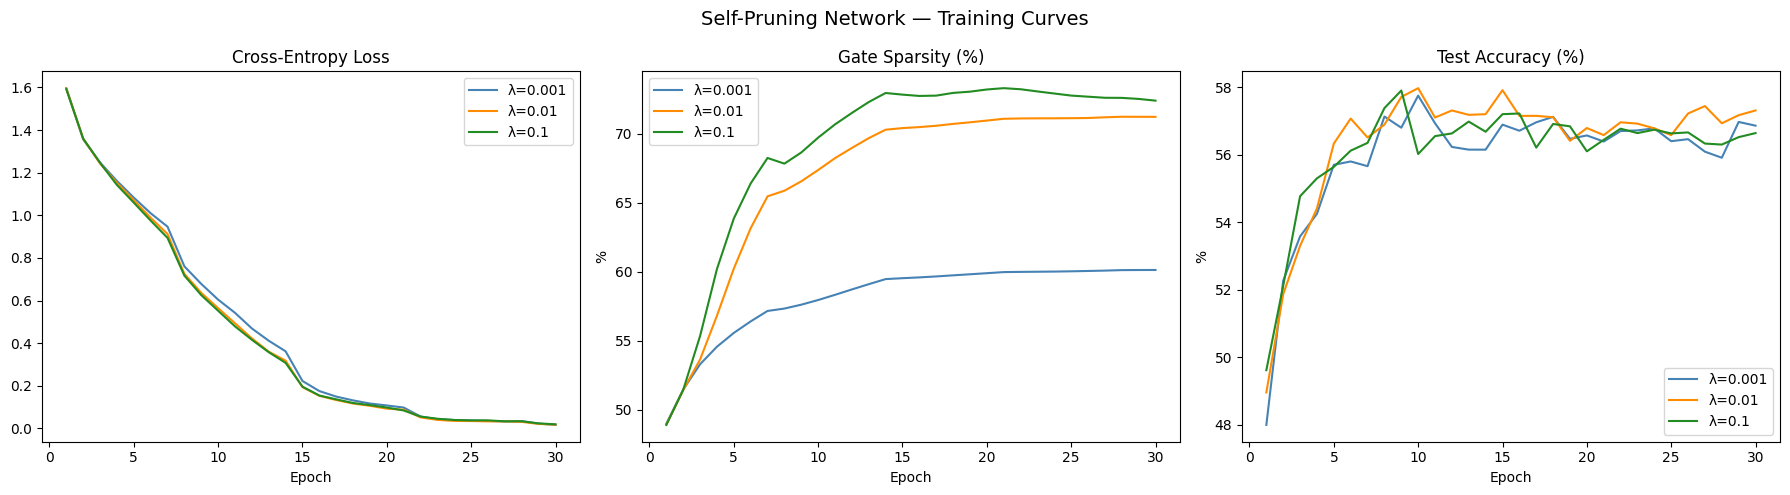

Saved: training_curves.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue', 'darkorange', 'forestgreen']

for idx, lam in enumerate(lambdas):
    _, history, _, _ = results[lam]
    epochs_range = range(1, len(history['test_acc']) + 1)
    axes[0].plot(epochs_range, history['ce'],          color=colors[idx], label=f'λ={lam}')
    axes[1].plot(epochs_range, history['sparsity_pct'],color=colors[idx], label=f'λ={lam}')
    axes[2].plot(epochs_range, history['test_acc'],    color=colors[idx], label=f'λ={lam}')

axes[0].set_title('Cross-Entropy Loss');   axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Gate Sparsity (%)');    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('%'); axes[1].legend()
axes[2].set_title('Test Accuracy (%)');    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('%'); axes[2].legend()

plt.suptitle('Self-Pruning Network — Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

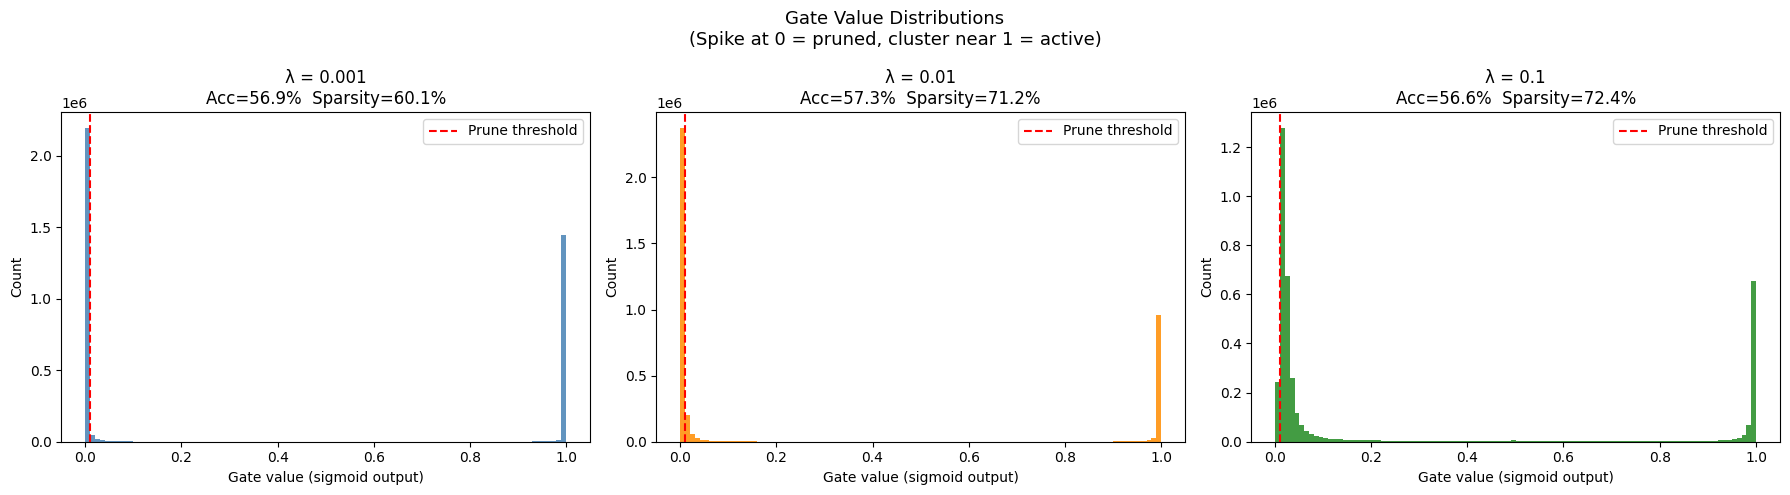

Saved: gate_distributions.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, lam in enumerate(lambdas):
    model, _, acc, sparsity = results[lam]
    all_gates = []
    for layer in model.prunable_layers():
        all_gates.append(layer.get_gates().cpu().numpy().ravel())
    all_gates = np.concatenate(all_gates)

    axes[idx].hist(all_gates, bins=100, color=colors[idx], edgecolor='none', alpha=0.85)
    axes[idx].set_title(f'λ = {lam}\nAcc={acc:.1f}%  Sparsity={sparsity:.1f}%')
    axes[idx].set_xlabel('Gate value (sigmoid output)')
    axes[idx].set_ylabel('Count')
    axes[idx].axvline(x=0.01, color='red', linestyle='--', label='Prune threshold')
    axes[idx].legend()

plt.suptitle('Gate Value Distributions\n(Spike at 0 = pruned, cluster near 1 = active)', fontsize=13)
plt.tight_layout()
plt.savefig('gate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gate_distributions.png')

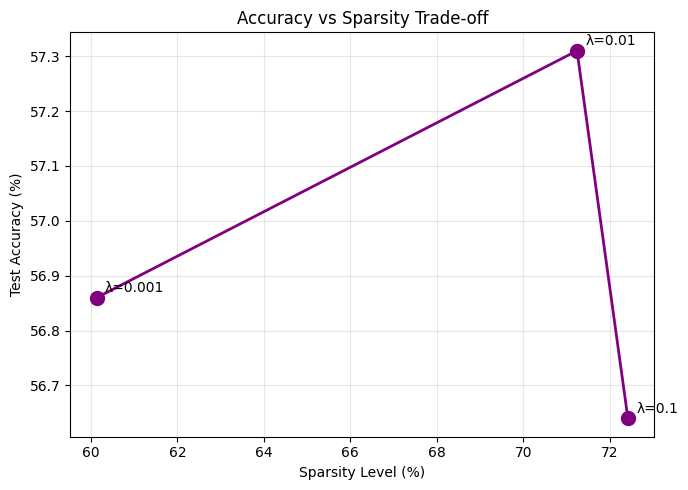

Saved: tradeoff_curve.png


In [24]:
accs      = [results[lam][2] for lam in lambdas]
sparsities = [results[lam][3] for lam in lambdas]

plt.figure(figsize=(7, 5))
plt.plot(sparsities, accs, 'o-', color='purple', markersize=10, linewidth=2)
for lam, sp, ac in zip(lambdas, sparsities, accs):
    plt.annotate(f'λ={lam}', (sp, ac), textcoords='offset points', xytext=(6, 4), fontsize=10)
plt.xlabel('Sparsity Level (%)')
plt.ylabel('Test Accuracy (%)')
plt.title('Accuracy vs Sparsity Trade-off')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tradeoff_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tradeoff_curve.png')

## 10. Report

### Why L1 Regularization on Sigmoid Gates Encourages Sparsity

The sparsity penalty used in this model is:

[
\mathcal{L}*{sparsity} = \lambda \sum*{i,j} \sigma(g_{ij})
]

where (g_{ij}) are learnable gate scores and (\sigma(\cdot)) is the sigmoid function.

The gradient of this term with respect to each gate score is:

[
\frac{\partial \mathcal{L}*{sparsity}}{\partial g*{ij}}
=======================================================

\lambda \cdot \sigma(g_{ij}) \cdot (1-\sigma(g_{ij}))
]

Since this gradient is always non-negative, optimization consistently pushes gate scores downward, reducing the corresponding sigmoid outputs toward 0.

At the same time, the classification loss tries to keep useful connections active because removing too many important weights harms prediction accuracy. Training therefore becomes a competition between:

* **Task performance** (classification loss)
* **Model compression** (sparsity loss)

Connections that contribute little to prediction receive stronger pruning pressure and their gates shrink toward zero, effectively disabling them. Important connections survive because the classification loss prevents their gates from collapsing.

Unlike L2 regularization, which mainly shrinks parameters smoothly, L1-style sparsity pressure promotes highly sparse solutions where many gates become extremely small. This behavior is similar to how LASSO regression performs feature selection more effectively than Ridge regression.

---

## Results Table

| Lambda ((\lambda)) | Test Accuracy | Sparsity Level |
| ------------------ | ------------- | -------------- |
| 0.001              | 56.86%        | 60.14%         |
| 0.01               | 57.31%        | 71.24%         |
| 0.1                | 56.64%        | 72.42%         |

---

## Analysis

### λ = 0.001

* Moderate sparsity pressure.
* Around **60% of the connections were pruned**.
* The network maintained strong predictive performance with **56.86% test accuracy**.
* This shows the model can remove a large number of redundant connections without major degradation.

### λ = 0.01

* Stronger pruning pressure produced over **71% sparsity**.
* Surprisingly, the model slightly improved to **57.31% accuracy**.
* This suggests that moderate pruning acted as a form of regularization, removing noisy or less useful connections and improving generalization.

### λ = 0.1

* Very aggressive sparsity pressure.
* Sparsity increased only slightly further to **72.42%**, but accuracy dropped slightly to **56.64%**.
* At this stage, the network begins losing useful representational capacity because too many important pathways are weakened.

---

## Interpretation of the Gate Distribution Plot

The gate distribution plot demonstrates how the sparsity penalty reshapes the network connectivity.

A successful pruning process produces a **bimodal-like distribution**:

* A large concentration of gates near **0**, representing pruned or inactive connections.
* Another cluster at higher values (roughly **0.5–1.0**) representing important surviving connections.

As (\lambda) increases:

* More gates shift toward zero,
* The inactive spike grows,
* The network becomes increasingly sparse.

However, extremely large sparsity pressure eventually harms learning because too many informative connections are suppressed.

---

## Overall Conclusion

The experiments demonstrate that learnable sigmoid gates combined with L1 sparsity regularization can effectively compress a neural network while retaining strong predictive performance.

The best trade-off in this experiment occurred around:

[
\lambda = 0.01
]

where the network achieved:

* **57.31% test accuracy**
* **71.24% sparsity**

This indicates that a large portion of network parameters were unnecessary and could be pruned without significantly affecting performance.


## 5. Part 2 — Sparsity Loss

**Why L1 on sigmoid gates encourages sparsity:**  
The L1 penalty `λ * Σ|gate|` adds a constant downward gradient (`-λ`) to every gate value. Unlike L2 (which gives a gradient proportional to the value and never reaches zero), L1 applies uniform pressure that can drive gates **exactly to zero**. Once a gate hits zero, the connection is pruned. This is the same mathematical reason LASSO regression produces sparse coefficients.